# 06 — Predictions
### Chicago Housing Market | Listing Risk Prediction

This is the final notebook in the pipeline. We take the best trained models from notebooks 04–05 and use them to **generate predictions and communicate findings** in a clear, visual way.

**What this notebook does:**
1. Load the best models and run predictions on the full dataset
2. Visualise predicted risk score over time vs actual
3. Highlight the highest-risk periods on a timeline
4. Show the top 10 riskiest months
5. Profile what high-risk vs low-risk periods look like

**Input:** Models from `models/` + `data/processed/chicago_housing_engineered.csv`

> **Important interpretation note:** This notebook uses the corrected 155-month dataset. Linear Regression was the better model for predicting the numeric risk score on the unseen test months. The high/low-risk classification visuals are exploratory because every month in the final test period was Low Risk, so high-risk classification could not be fully evaluated.


### What is a Prediction Pipeline?

A **prediction pipeline** is the sequence of steps you apply to turn raw input data into a model output:

```
Raw data → Feature Engineering → Scaling → Model → Prediction
```

In production (a real app or dashboard), this pipeline would run every month when new Redfin data is released. The model would output a risk score for Chicago, which could be shown to real estate agents or investors.

In this notebook, we run the pipeline over the full historical dataset to visualise how risk has evolved over time.

### What are we doing in this cell?

We load the best-performing models identified in notebook 05: Linear Regression for risk-score prediction and Logistic Regression for high/low-risk classification. We also load the scaler, the feature column list, and the full engineered dataset.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

# Load the best models from Notebook 5
lr      = joblib.load('../models/linear_regression.pkl')
log_clf = joblib.load('../models/logistic_regression.pkl')
scaler  = joblib.load('../models/scaler.pkl')
FEATURE_COLS = joblib.load('../models/feature_cols.pkl')

# Load full engineered dataset
df = pd.read_csv('../data/processed/chicago_housing_engineered.csv')
df['PERIOD_BEGIN'] = pd.to_datetime(df['PERIOD_BEGIN'])
df = df.sort_values('PERIOD_BEGIN').reset_index(drop=True)

print(f'Loaded: {df.shape}')
print(f'Date range: {df["PERIOD_BEGIN"].min().date()}  →  {df["PERIOD_BEGIN"].max().date()}')

Loaded: (155, 41)
Date range: 2013-02-01  →  2025-12-01


---
## 1. Predict on Full Dataset

### What are we doing in this cell?

We run both models over **all** rows in the engineered dataset — including the training period. This gives us a continuous historical risk timeline we can visualise end-to-end.

We attach the predictions as new columns to the DataFrame so we can work with them easily in subsequent cells.

In [18]:
X_all_sc = scaler.transform(df[FEATURE_COLS])

df['PRED_RISK_SCORE'] = lr.predict(X_all_sc)
df['PRED_RISK_LABEL'] = log_clf.predict(X_all_sc)
df['PRED_RISK_PROB']  = log_clf.predict_proba(X_all_sc)[:, 1]  # probability of high risk

# There is already one Chicago metro record per month, so no aggregation is needed.
monthly_timeline = df.copy()

print(f'PRED_RISK_SCORE range: {df["PRED_RISK_SCORE"].min():.3f}  →  {df["PRED_RISK_SCORE"].max():.3f}')
print(f'PRED_RISK_LABEL:  High-risk rows: {df["PRED_RISK_LABEL"].sum()} / {len(df)}')
print(f'Monthly timeline: {len(monthly_timeline)} months')
df[['PERIOD_BEGIN', 'RISK_SCORE', 'PRED_RISK_SCORE', 'RISK_LABEL', 'PRED_RISK_LABEL']].head(5)

PRED_RISK_SCORE range: -1.651  →  1.109
PRED_RISK_LABEL:  High-risk rows: 60 / 155
Monthly timeline: 155 months


,PERIOD_BEGIN,RISK_SCORE,PRED_RISK_SCORE,RISK_LABEL,PRED_RISK_LABEL
0,2013-02-01,0.914440,0.976855,0,0
1,2013-03-01,0.368770,0.410055,0,0
2,2013-04-01,0.036273,0.306166,1,1
3,2013-05-01,-0.192827,-0.087296,1,1
4,2013-06-01,-0.317051,-0.310453,0,1


---
## 2. Predicted Risk Score Over Time

### What are we doing in this cell?

We plot the **actual** RISK_SCORE vs the **predicted** RISK_SCORE side-by-side over the full timeline.

A vertical dashed line marks the train/test split. The left side of the line is where the model learned; the right side is the real test — unseen data. If the predicted line still tracks the actual line on the right, the model generalises well.

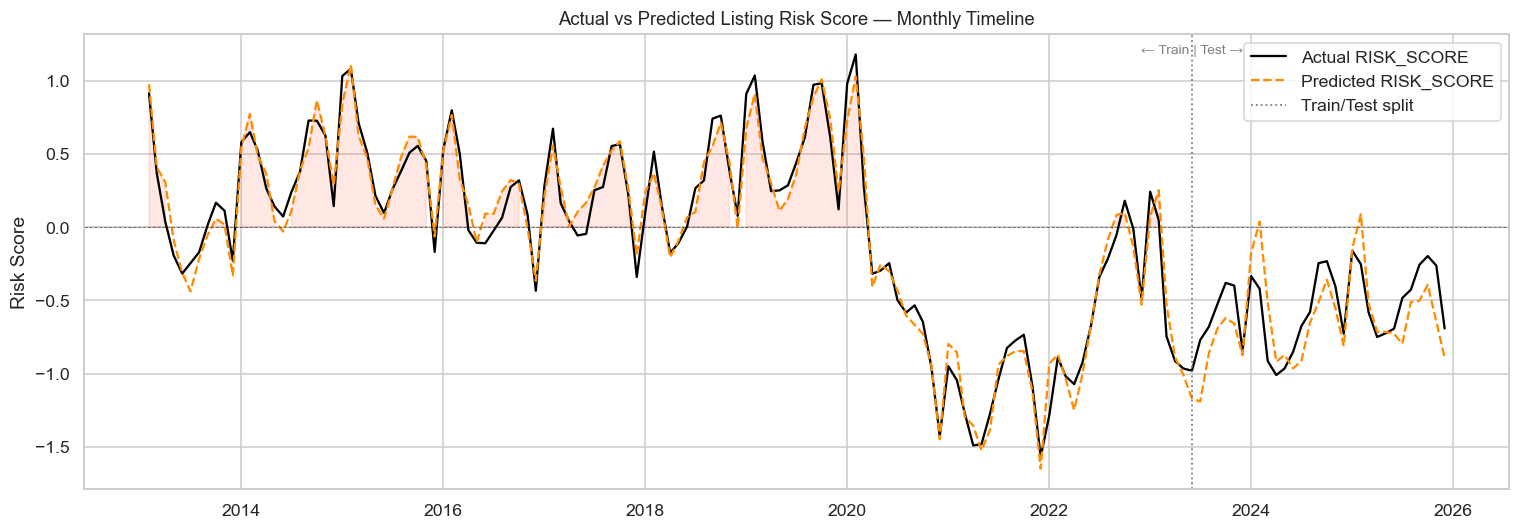

In [13]:
train_size = int(len(monthly_timeline) * 0.8)
split_date = monthly_timeline['PERIOD_BEGIN'].tail(len(monthly_timeline) - train_size).min()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_timeline['PERIOD_BEGIN'], monthly_timeline['RISK_SCORE'],      color='black',      linewidth=1.5, label='Actual RISK_SCORE')
ax.plot(monthly_timeline['PERIOD_BEGIN'], monthly_timeline['PRED_RISK_SCORE'], color='darkorange', linewidth=1.5, linestyle='--', label='Predicted RISK_SCORE')
ax.axvline(split_date, color='grey', linewidth=1.2, linestyle=':', label='Train/Test split')
ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.5)
ax.fill_between(monthly_timeline['PERIOD_BEGIN'], monthly_timeline['PRED_RISK_SCORE'],
                where=monthly_timeline['PRED_RISK_SCORE'] > 0, color='tomato', alpha=0.15)
ax.text(split_date, ax.get_ylim()[1] * 0.9, '← Train | Test →',
        ha='center', fontsize=9, color='grey')
ax.set_title('Actual vs Predicted Listing Risk Score — Monthly Timeline', fontsize=12)
ax.set_ylabel('Risk Score')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. High-Risk Period Detection

### What are we doing in this cell?

We create a **risk timeline** that highlights the months the model flagged as high-risk (PRED_RISK_LABEL = 1) with shaded red bands.

This is the kind of visualisation a real estate professional or investor would actually use — quickly scan a timeline and see which periods had elevated listing risk, then cross-reference with historical events (interest rate hikes, economic downturns, pandemic).

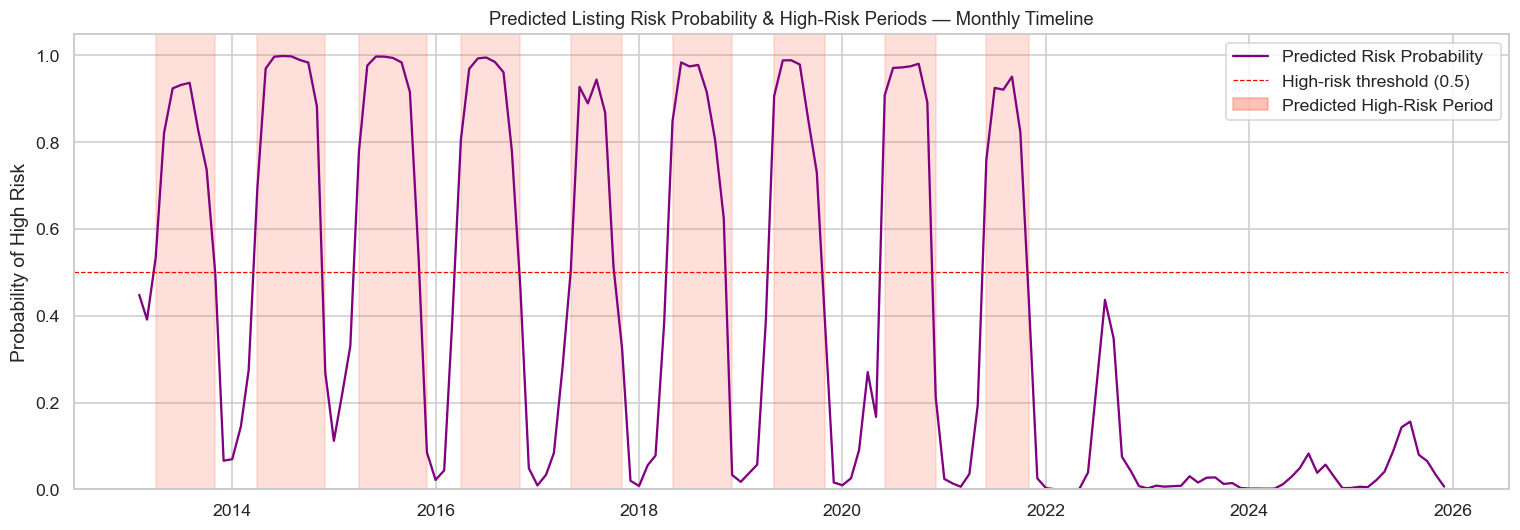

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_timeline['PERIOD_BEGIN'], monthly_timeline['PRED_RISK_PROB'], color='purple', linewidth=1.5, label='Predicted Risk Probability')
ax.axhline(0.5, color='red', linewidth=0.8, linestyle='--', label='High-risk threshold (0.5)')

# Shade high-risk periods
in_band = False
start = None
for _, row in monthly_timeline.iterrows():
    if row['PRED_RISK_LABEL'] == 1 and not in_band:
        start = row['PERIOD_BEGIN']
        in_band = True
    elif row['PRED_RISK_LABEL'] == 0 and in_band:
        ax.axvspan(start, row['PERIOD_BEGIN'], color='tomato', alpha=0.2)
        in_band = False
if in_band:
    ax.axvspan(start, monthly_timeline['PERIOD_BEGIN'].max(), color='tomato', alpha=0.2)

high_patch = mpatches.Patch(color='tomato', alpha=0.4, label='Predicted High-Risk Period')
ax.legend(handles=[ax.lines[0], ax.lines[1], high_patch])
ax.set_title('Predicted Listing Risk Probability & High-Risk Periods — Monthly Timeline', fontsize=12)
ax.set_ylabel('Probability of High Risk')
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()

---
## 4. Top 10 Highest-Risk Predicted Months

### What are we doing in this cell?

We sort all months by predicted risk score and print the top 10. Alongside the predicted score we also show the actual values of the three risk indicators (`PRICE_DROPS`, `MEDIAN_DOM`, `MONTHS_OF_SUPPLY`) so we can validate that the model is flagging genuinely risky periods.

Top 10 Highest-Risk Predicted Months:
PERIOD_BEGIN  PRED_RISK_SCORE  PRED_RISK_PROB  PRICE_DROPS  MEDIAN_DOM  MONTHS_OF_SUPPLY  RISK_SCORE
     2015-02            1.109           0.225        0.188        80.0               6.1       1.083
     2020-02            1.031           0.026        0.155       102.0               5.8       1.180
     2019-10            1.011           0.731        0.262        76.0               4.6       0.984
     2013-02            0.977           0.448        0.194        74.0               5.8       0.914
     2019-02            0.912           0.038        0.156        92.0               5.9       1.037
     2019-09            0.889           0.850        0.259        71.0               4.9       0.973
     2014-10            0.867           0.984        0.301        50.0               4.5       0.727
     2015-01            0.843           0.112        0.215        70.0               6.0       1.033
     2014-02            0.774           0.145        

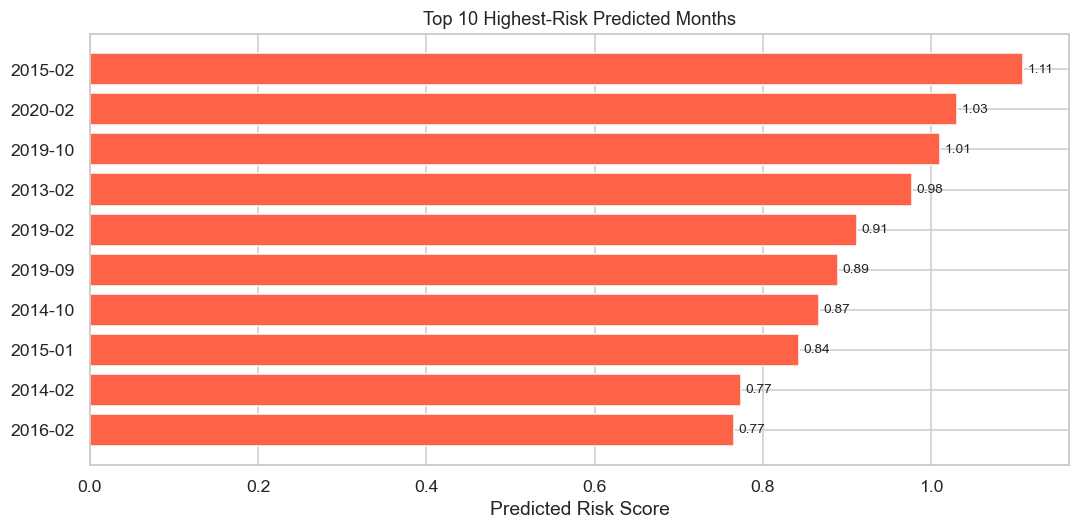

In [ ]:
top10 = (
    df[['PERIOD_BEGIN', 'PRED_RISK_SCORE', 'PRED_RISK_PROB',
        'PRICE_DROPS', 'MEDIAN_DOM', 'MONTHS_OF_SUPPLY', 'RISK_SCORE']]
    .sort_values('PRED_RISK_SCORE', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10['PERIOD_BEGIN'] = top10['PERIOD_BEGIN'].dt.strftime('%Y-%m')
top10 = top10.round(3)
print('Top 10 Highest-Risk Predicted Months:')
print(top10.to_string(index=False))

# Visualise
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10['PERIOD_BEGIN'], top10['PRED_RISK_SCORE'], color='tomato')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_xlabel('Predicted Risk Score')
ax.set_title('Top 10 Highest-Risk Predicted Months', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 5. High-Risk vs Low-Risk Feature Profiles

### What are we doing in this cell?

We compare the **average values of all features** during predicted high-risk vs low-risk months. This answers the question: *What does a high-risk market look like, vs a low-risk market?*

This is useful for communicating model insights to someone who doesn't understand machine learning — you can say: "In high-risk months, the median days on market is typically X days longer and price drops are Y% higher."

Average feature values by predicted risk label:
                   Low Risk (0)  High Risk (1)  % Difference
MEDIAN_SALE_PRICE     280847.46      236303.33         -15.9
HOMES_SOLD              6786.24        9341.62          37.7
NEW_LISTINGS            8648.14       11555.43          33.6
INVENTORY              23023.74       32041.38          39.2
MONTHS_OF_SUPPLY           3.55           3.53          -0.6
MEDIAN_DOM                57.32          43.92         -23.4
PRICE_DROPS                0.17           0.26          55.6


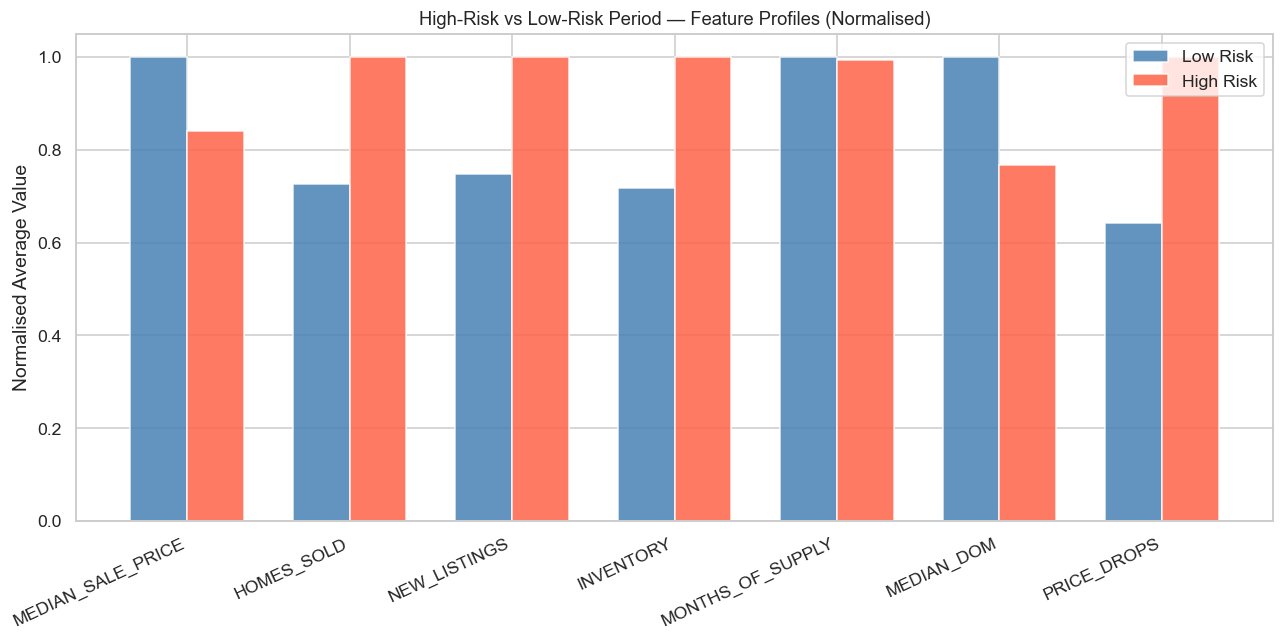

In [16]:
PROFILE_COLS = ['MEDIAN_SALE_PRICE', 'HOMES_SOLD', 'NEW_LISTINGS',
                'INVENTORY', 'MONTHS_OF_SUPPLY', 'MEDIAN_DOM', 'PRICE_DROPS']

profile = df.groupby('PRED_RISK_LABEL')[PROFILE_COLS].mean().T
profile.columns = ['Low Risk (0)', 'High Risk (1)']
profile['% Difference'] = ((profile['High Risk (1)'] - profile['Low Risk (0)']) / profile['Low Risk (0)'] * 100).round(1)

print('Average feature values by predicted risk label:')
print(profile.round(2).to_string())

# Normalise for side-by-side bar chart
profile_norm = profile[['Low Risk (0)', 'High Risk (1)']].apply(lambda x: x / x.max(), axis=1)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(PROFILE_COLS))
width = 0.35
bars1 = ax.bar(x - width/2, profile_norm['Low Risk (0)'],  width, label='Low Risk',  color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, profile_norm['High Risk (1)'], width, label='High Risk', color='tomato',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(PROFILE_COLS, rotation=25, ha='right')
ax.set_ylabel('Normalised Average Value')
ax.set_title('High-Risk vs Low-Risk Period — Feature Profiles (Normalised)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

---
## Final Summary

### What we built

A complete end-to-end listing risk prediction system for the Chicago housing market:

| Notebook | Purpose | Key output |
|----------|---------|------------|
| 01 | Data Preparation | Clean CSV from raw Redfin data |
| 02 | Exploratory Analysis | Visual understanding of all features |
| 03 | Feature Engineering | Lags, rolling averages, risk targets |
| 04 | Model Training | 4 trained models saved to disk |
| 05 | Model Evaluation | Test-set metrics, feature importance |
| 06 | Predictions | Risk timeline, top-10 risky months, feature profiles |

### Limitations

- **Small dataset** — 155 monthly observations for one Chicago metro series. More granular (weekly or zip-code level) data would improve predictions.
- **No external features** — interest rates, unemployment, and GDP are strong housing market drivers not included here.
- **Classification test limitation** — the final 31 test months were all Low Risk, so ROC/AUC and a full high-risk classification evaluation were not possible.

### Possible next steps

1. Add macroeconomic features (mortgage rates, CPI, unemployment)
2. Extend to all US metro areas using the full Redfin dataset
3. Build a real-time prediction dashboard in PowerBI or Streamlit
4. Try LSTM or other time-series-aware neural networks